In [1]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
import matplotlib.pyplot as plt

c:\Users\ferdy\development\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
img_size = (224, 224)
batch_size = 32

In [3]:
train_ds = image_dataset_from_directory(
    "../../dataset_split/train",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

Found 4631 files belonging to 5 classes.


In [4]:
val_ds = image_dataset_from_directory(
    "../../dataset_split/val",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

Found 578 files belonging to 5 classes.


In [5]:
test_ds_raw = image_dataset_from_directory(
    "../../dataset_split/test",
    label_mode='categorical',
    image_size=img_size,
    batch_size=batch_size,
    shuffle=False
)

Found 581 files belonging to 5 classes.


In [6]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds_raw.prefetch(buffer_size=AUTOTUNE)

In [7]:
base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=(224, 224, 3))
base_model.trainable = False

In [8]:
inputs = Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x)
outputs = Dense(5, activation='softmax')(x)
model = Model(inputs, outputs)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15


145/145 [==============================] - 79s 462ms/step - loss: 0.5479 - accuracy: 0.8296 - val_loss: 0.2179 - val_accuracy: 0.9567
Epoch 2/15
145/145 [==============================] - 65s 450ms/step - loss: 0.2158 - accuracy: 0.9426 - val_loss: 0.1422 - val_accuracy: 0.9602
Epoch 3/15
145/145 [==============================] - 87s 602ms/step - loss: 0.1611 - accuracy: 0.9557 - val_loss: 0.1120 - val_accuracy: 0.9671
Epoch 4/15
145/145 [==============================] - 89s 609ms/step - loss: 0.1312 - accuracy: 0.9663 - val_loss: 0.0906 - val_accuracy: 0.9792
Epoch 5/15
145/145 [==============================] - 76s 521ms/step - loss: 0.1174 - accuracy: 0.9674 - val_loss: 0.0803 - val_accuracy: 0.9775
Epoch 6/15
 43/145 [=======>......................] - ETA: 47s - loss: 0.1051 - accuracy: 0.9702

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"\nAkurasi di data test: {test_acc:.2%}")

19/19 [==============================] - 6s 301ms/step - loss: 0.0558 - accuracy: 0.9845

✅ Akurasi di data test: 98.45%


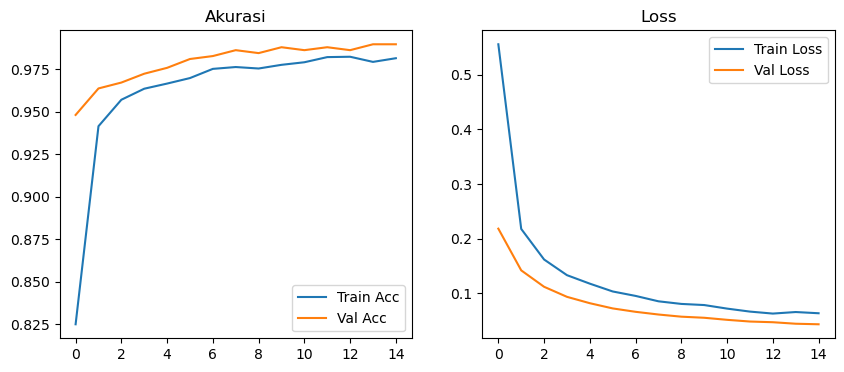

In [13]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Akurasi')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [14]:
model.save("../../model/soil_texture_classifier.h5")

c:\Users\ferdy\development\anaconda\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
y_pred = model.predict(test_ds)
y_pred_labels = np.argmax(y_pred, axis=1)

19/19 [==============================] - 5s 279ms/step


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.float32, name=None))>

In [26]:
y_true = np.concatenate([np.argmax(y, axis=1) for x, y in test_ds_raw], axis=0)

In [27]:
cm = confusion_matrix(y_true, y_pred_labels)
class_names = test_ds_raw.class_names

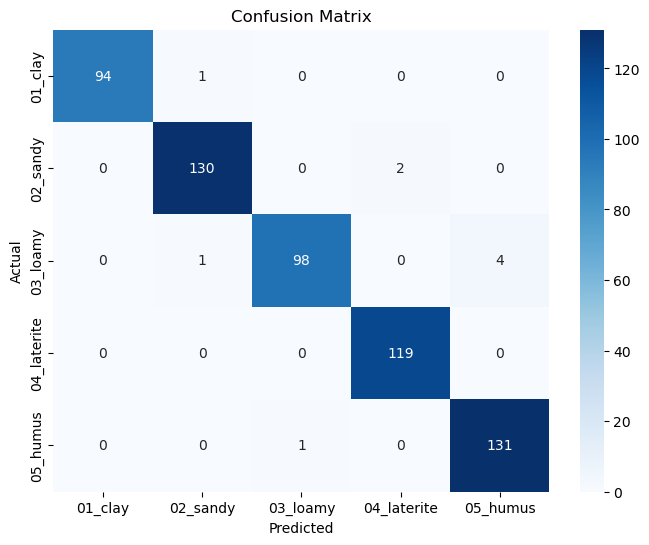

In [28]:
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [29]:
print(classification_report(y_true, y_pred_labels, target_names=class_names))

              precision    recall  f1-score   support

     01_clay       1.00      0.99      0.99        95
    02_sandy       0.98      0.98      0.98       132
    03_loamy       0.99      0.95      0.97       103
 04_laterite       0.98      1.00      0.99       119
    05_humus       0.97      0.99      0.98       132

    accuracy                           0.98       581
   macro avg       0.99      0.98      0.98       581
weighted avg       0.98      0.98      0.98       581

